# Assignment Part 1

### Understanding of Data section
**Get a general understanding of the data (for example, how many data points in total, the
percentage of each category, the distribution of character lengths for the category by using
visualization, etc**

In [1]:
#Imports
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
import seaborn as sb
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
from nltk.corpus import stopwords
import re
from collections import Counter
import openpyxl #For import excel files, some how i cant read excel with out this library here using pandas read excel
import spacy
from nltk.probability import FreqDist


In [2]:
#Importing file into ipynb file and making it into a dataframe
df = pd.DataFrame(pd.read_excel('Data/Data.xlsx'))
df

,description,species
0,2 Jun 2023 ï¿½ The Javan myna shares some simi...,Javan Myna
1,Click here for more information about the Red ...,Collared Kingfisher
2,The black-headed oriole ( Oriolus larvatus) is...,Black-naped Oriole
3,"Search from thousands of royalty-free ""Javan M...",Javan Myna
4,521 foreground recordings and 156 background ...,Little Egret
...,...,...
737,"August 13, 2016 - HISTORICAL records show that...",Little Egret
738,File: Black-naped Oriole (Oriolus chinensis ch...,Black-naped Oriole
739,Larger than a Cattle Egret and with black leg...,Little Egret
740,22 Oct 2023 ï¿½ Dragon Snake (Javan Tubercle S...,Javan Myna


In [3]:
# Display basic information about the dataset
'''
The dataset has 742 rows of data with two columns: description and species.
The description column has 718 non-null rows,
so there are missing value. 742 - 718 is 24 missing values / information / data
While The species column has all values present.

This also shows me how many duplicate there are, and i have to remove it
'''

data_info = df.info()
data_head = df.head()
duplicate = df.duplicated().sum()

print(data_info,'\n')
print(f'Data first 5 rows: {data_head}\n')
print(f'Data duplicates: {duplicate}\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   description  718 non-null    object
 1   species      742 non-null    object
dtypes: object(2)
memory usage: 11.7+ KB
None 

Data first 5 rows:                                          description              species
0  2 Jun 2023 ï¿½ The Javan myna shares some simi...           Javan Myna
1  Click here for more information about the Red ...  Collared Kingfisher
2  The black-headed oriole ( Oriolus larvatus) is...   Black-naped Oriole
3  Search from thousands of royalty-free "Javan M...           Javan Myna
4   521 foreground recordings and 156 background ...         Little Egret

Data duplicates: 128



In [4]:
'''
Drop rows with missing descriptions for now.
As i want to show the actual distrubtion for proper data understanding.
Since i will still be dropping missing descriptions row as part of pre-process.
Despite this just being data understanding. I want to show all rows that only contain data.
'''
data_cleaned = df.dropna(subset=['description'])

In [5]:
#Analysis what are the percentage and count of distribution of species
species_counts = data_cleaned['species'].value_counts()
species_counts_percentage = round(data_cleaned['species'].value_counts(normalize=True) * 100,2)

# Calculate character length and the average word length of each description
data_cleaned.loc[:, 'char_length'] = data_cleaned.loc[:, 'description'].apply(lambda x: len(x.split())) # I used this for good coding practice, i wanted to not use loc, but due to SettingWithCopyWarning warning me about bad coding practices.
avg_length = data_cleaned.groupby('species')['char_length'].mean().round(2).sort_values(ascending=False)

# shows species distribution and display first few entries and average character in each species for training the model later on
print(f'The species distribution by count:\n{species_counts}\n')
print(f'The species distribution by percentage:\n{species_counts_percentage}\n')
print(f'The species average description word:\n{avg_length}')

The species distribution by count:
species
Black-naped Oriole     208
Javan Myna             199
Little Egret           163
Collared Kingfisher    148
Name: count, dtype: int64

The species distribution by percentage:
species
Black-naped Oriole     28.97
Javan Myna             27.72
Little Egret           22.70
Collared Kingfisher    20.61
Name: proportion, dtype: float64

The species average description word:
species
Collared Kingfisher    46.94
Black-naped Oriole     42.62
Javan Myna             30.86
Little Egret           29.26
Name: char_length, dtype: float64


C:\Users\zhoul\AppData\Local\Temp\ipykernel_17804\1116382332.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned.loc[:, 'char_length'] = data_cleaned.loc[:, 'description'].apply(lambda x: len(x.split())) # I used this for good coding practice, i wanted to not use loc, but due to SettingWithCopyWarning warning me about bad coding practices.


### Species Distribution Pie Chart

**Use a piechart to show you the species distribution**<br>
This pie chart shows me that the distribution among this 4 species are quite balanced for now before cleaning.

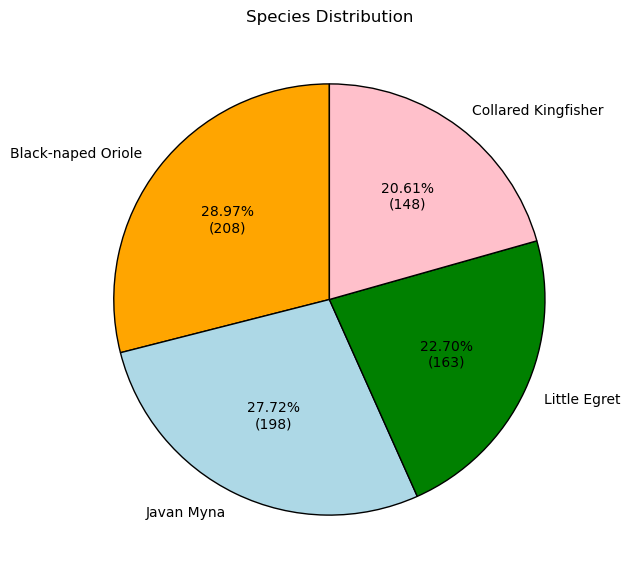

In [6]:
# Species Distribution Pie Chart
species_counts = data_cleaned['species'].value_counts()  # Find the total count of each species
total_species_count = data_cleaned['species'].count()  # Total species count

#Color for the bar chart
colors=['Orange','Lightblue','Green','Pink']

plt.figure(figsize=(7, 7))

# Create the pie chart
plt.pie(
    species_counts.values, # Values from the species count variable 
    labels=species_counts.index,  # Labels for each part of the pie chart
    colors=colors, #Color set to the colors list
    autopct=lambda p: f'{p:.2f}%\n({int(p * total_species_count / 100)})',  # autopct that calculate the percentage and count
    startangle=90,  # Sort the pie chart ascending
    wedgeprops={'edgecolor': 'black'}  # Add edge color for better visibility
)

# Add a custom legend
#plt.legend(
#    labels=species_counts.index,  # Species names as labels
#    title='Species',
#    loc='upper right'  # Place the legend in the best location
#)
plt.tight_layout
plt.title('Species Distribution')
plt.show()

### Species Analysis using Box Plot

**Use a Box Plot to show you the species words distribution like value that is outliers(1.5 time more or below than sigma), mean and etc**

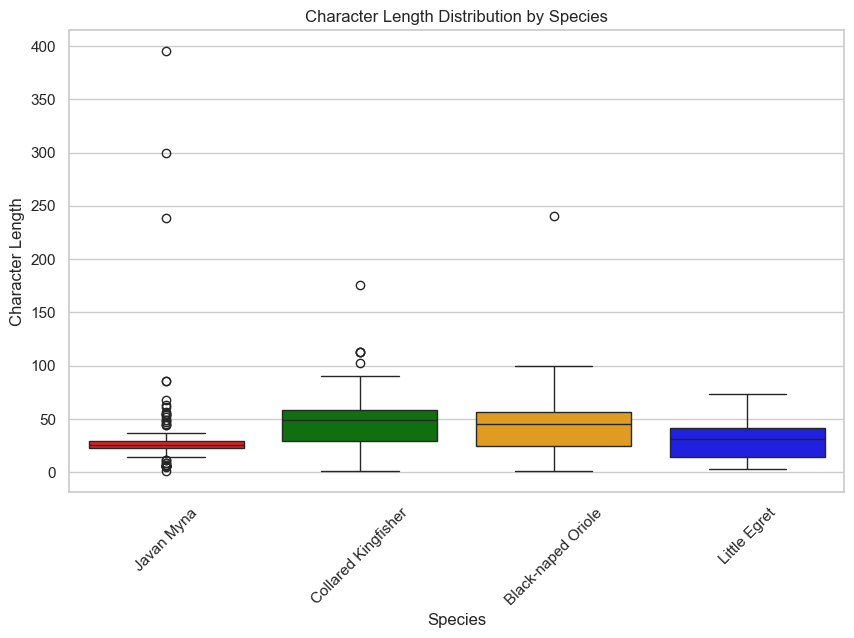

In [7]:
# Set the style for the plot
sb.set(style="whitegrid")

colours = ['red','green','orange','blue']
# Plot character length distribution by species
plt.figure(figsize=(10, 6))
sb.boxplot(x='species', y='char_length', data=data_cleaned, hue='species',palette=colours)
plt.title('Character Length Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Character Length')
plt.xticks(rotation=45)
plt.show()



### Data Pre-Processing Section
**Apply pre-processing steps/techniques to the text (for example, remove all words that
contain numbers, make all the text lowercase, etc.**

In [8]:
#Importing file into ipynb file and making it into a dataframe
pre_processing_df = pd.DataFrame(pd.read_excel('Data/Data.xlsx'))
pre_processing_df

,description,species
0,2 Jun 2023 ï¿½ The Javan myna shares some simi...,Javan Myna
1,Click here for more information about the Red ...,Collared Kingfisher
2,The black-headed oriole ( Oriolus larvatus) is...,Black-naped Oriole
3,"Search from thousands of royalty-free ""Javan M...",Javan Myna
4,521 foreground recordings and 156 background ...,Little Egret
...,...,...
737,"August 13, 2016 - HISTORICAL records show that...",Little Egret
738,File: Black-naped Oriole (Oriolus chinensis ch...,Black-naped Oriole
739,Larger than a Cattle Egret and with black leg...,Little Egret
740,22 Oct 2023 ï¿½ Dragon Snake (Javan Tubercle S...,Javan Myna


**Part 1 of Data Cleaning**<br>
This portion, I started cleaning the data using the function preprocess_part1. It takes in the df and columns to process.<br>
Firstly, drop all missing values in the df[column], then drop all duplicates too.


In [9]:
def preprocess_part1(df,column): #Function to drop missing value and duplicate
    df = df.dropna(subset=[column]) #drop missing value
    df = df.drop_duplicates(keep='first').reset_index(drop=True) #drop duplicate                                                                     
    return df
    
pre_processing_df = preprocess_part1(pre_processing_df,'description') #Run the function here

pre_processing_df #Print the DF here to look at it

,description,species
0,2 Jun 2023 ï¿½ The Javan myna shares some simi...,Javan Myna
1,Click here for more information about the Red ...,Collared Kingfisher
2,The black-headed oriole ( Oriolus larvatus) is...,Black-naped Oriole
3,"Search from thousands of royalty-free ""Javan M...",Javan Myna
4,521 foreground recordings and 156 background ...,Little Egret
...,...,...
606,Black-naped Oriole (Oriolus chinensis). The bl...,Black-naped Oriole
607,"Feb 15, 2023 Â· Sacred kingfisher. Todiramphu...",Collared Kingfisher
608,"August 13, 2016 - HISTORICAL records show that...",Little Egret
609,File: Black-naped Oriole (Oriolus chinensis ch...,Black-naped Oriole


# Data Cleaning Part 2
This section will include functions to lemmatize words, remove and replace puncuation, text/word found by regex, dates, months, encoding errors.<br>
This will also change expand on abbrevations. Example: sep -> september.

Function **replace_month_abbrev(text)** Replace month abbreviation with full form.<br>
Function **remove_encoded_text(text)** clean text and handle encoding issues like �<br>
Function **preprocess_word(word)** preprocess text at word level, like removing stop words, removing months and filtering out words less than 3 character length<br>
Function **preprocess_text(text)** preprocess word, like removing stop words, removing months and lemmatizing words. <br>In this function, it will also be using other functions like *remove_encoded_text(text)*, *preprocess_word(word)*. Using Spacy English Core Sm for Lemmatization, word tokenizer and regex to filter out words too. <br>
Lastly, **preprocess_part2(df,column)**. This will use all of the above function to clean the data.


In [10]:
# Replace month abbreviation with full form
def replace_month_abbrev(text):

    #Dictionary of months abbreviation to full form
    abbrev_month = {
        "jan": "january",
        "feb": "february",
        "mar": "march",
        "apr": "april",
        "jun": "june",
        "jul": "july",
        "aug": "august",
        "sep": "september",
        "sept": "september",
        "oct": "october",
        "nov": "november",
        "dec": "december",
    }

    # if text has the abbreviation of momth, it will get replace to its full form
    for short_form, full_form in abbrev_month.items():
        text = re.sub(rf'\b{short_form}\b', full_form, text) #Replace the abbreviated months to full form from the abbrev_month dictionary above. 
    return text

# Function to clean text and handle encoding issues
def remove_encoded_text(text):
    # Ensure the text is decoded correctly
    if isinstance(text, bytes):  # Decode bytes if necessary
        text = text.decode('utf-8', errors='replace')  # the character � as placeholder character
    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', '', text)  #This regex replace anything not in the ASCII character / table as blank
    return text

# Function to preprocess text at word level
def preprocess_word(word):

    # Define stop words
    stop_words = set(stopwords.words('english'))
    stop_words.add('also')
    stop_words.add('much')
    stop_words.add('may')
    
    months = {"january","february","march","april","june","july","august","september","october","november","december"}

    # Remove stop words
    word = replace_month_abbrev(word)
    
    if word in stop_words:
        return None
        
    #Remove the months, Do no more dates
    if word in months:
        return None
        
    #If word length less than 3, remove it
    if len(word) < 3:
        return None
    # if lemma_words in words_to_remove_after_lemma:
    #     return None
    return word

# Function to preprocess text
def preprocess_text(text):
    
    # Initialize English Core Sm for Lemmatization
    nlp = spacy.load('en_core_web_sm')
    
    # Clean the text
    text = remove_encoded_text(text)
    
    # Remove numbers and punctuation
    text = re.sub(r'-','',text)

    # Remove words with numbers
    text = re.sub(r'\b\w*\d\w*\b', ' ', text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Split camel Case and Pascal Case words
    text = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', text)

    # Tokenize into words
    text = text.lower()
    
    words = word_tokenize(text)
    # Preprocess each word
    processed_words = []
    for word in words:
        word = nlp(word) # Put the words through En Core Web Sm
        lemma_word = word[0].lemma_.lower()
        processed = preprocess_word(lemma_word)
        if processed:  # Include only if preprocess_word() returns a value
            processed_words.append(processed)
    return processed_words

#The function below will use all of the function above to pre-process / clean the data in the dataframe
def preprocess_part2(df,column):
        df['processed_words'] = df[column].apply(preprocess_text) # apply the other functions to clean this DF 
        df['processed_words'] = [' '.join(x) for x in df['processed_words']] #Make a new column for the new cleaned data
        df = df.drop(columns=column) #Drop the uncleaned data column as i only want to keep the original columns
        df = df.drop_duplicates().reset_index(drop=True)
        return df

pre_processing_df = preprocess_part2(pre_processing_df,'description') #Clean the data using this function
pre_processing_df #Print out the Data frame

,species,processed_words
0,Javan Myna,javan myna share similarity common myna term p...
1,Collared Kingfisher,click information red list category criterion ...
2,Black-naped Oriole,blackheade oriole oriolus larvatus specie bird...
3,Javan Myna,search thousand royaltyfree javan myna stock i...
4,Little Egret,foreground recording background recording egre...
...,...,...
578,Black-naped Oriole,identification record blacknape oriole oriolus...
579,Black-naped Oriole,blacknape oriole oriolus chinensis blacknape o...
580,Collared Kingfisher,sacred kingfisher todiramphus sanctus length w...
581,Little Egret,historical record show little egret egretta ga...


# Export the file


In [11]:
pre_processing_df.to_csv('Data/234707R_cleaned_data.csv', index=False)

# Most common words in this dataset

I have shown a list of top 50 words in a form of **Text**, **Bar Chart** and **Word Cloud**. By looking at these, i am able to see that the top 3 most common words are oriole, bird and kingfisher. These visualisation also shows me what factors / feature that will be used for training the model later on.

In [12]:
# Combine all processed words into a single list
all_words = []
for row in pre_processing_df['processed_words']:
    all_words.extend(row.split(' '))  # Split words that were joined by ' '

# Use FreqDist to calculate word frequencies
freq_dist = FreqDist(all_words)

# Get the 50 most common words
most_common_words = freq_dist.most_common(50)

# Display the most common words
print("Top 50 Most Common Words:")
for word, count in most_common_words:
    print(f"{word}: {count}")


Top 50 Most Common Words:
oriole: 283
bird: 281
kingfisher: 279
myna: 217
specie: 181
javan: 142
black: 141
blacknape: 123
egret: 118
white: 112
find: 94
collared: 86
little: 83
yellow: 82
oriolus: 81
common: 79
singapore: 74
range: 70
bill: 68
family: 60
chinensis: 54
name: 53
forest: 53
know: 52
include: 51
world: 50
call: 50
acridothere: 49
eye: 49
subspecie: 48
see: 47
one: 45
blue: 44
male: 44
female: 44
small: 43
habitat: 42
asia: 42
wing: 39
size: 38
javanicu: 38
photo: 37
part: 37
tail: 37
large: 36
bright: 36
population: 35
back: 35
golden: 34
tree: 32


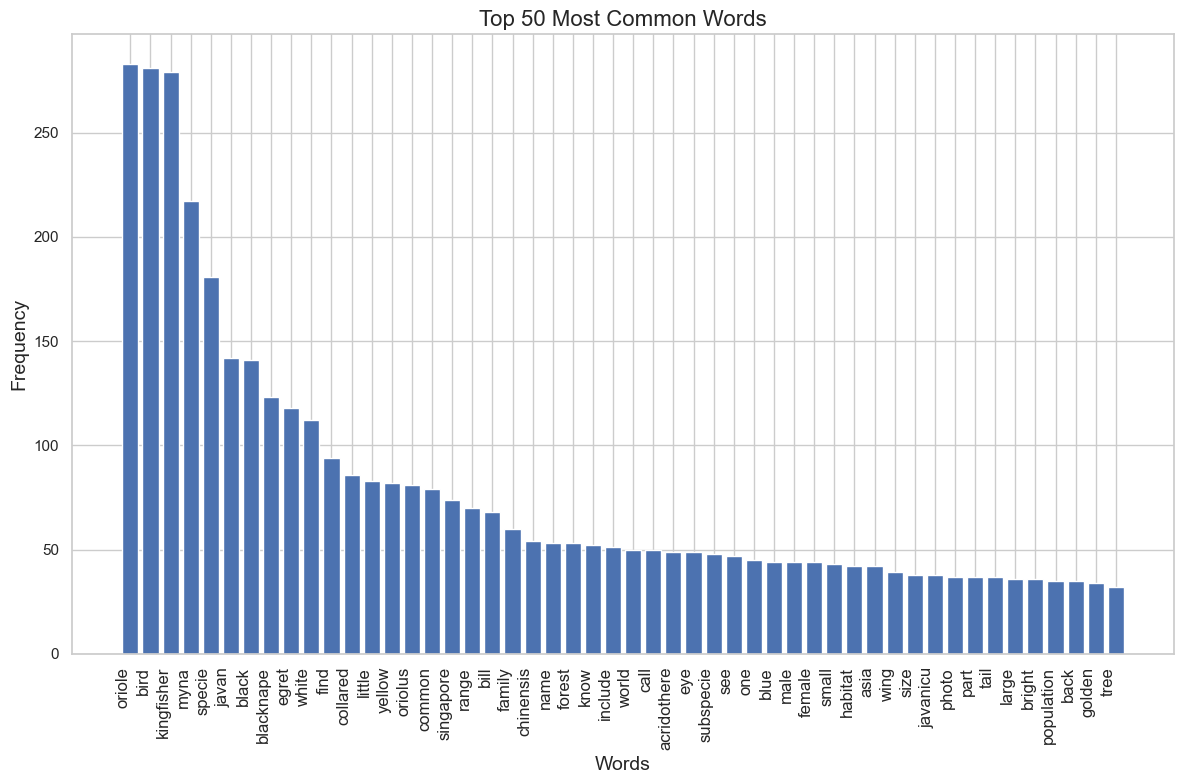

In [13]:
#Plot the most common words
most_common_words = freq_dist.most_common(50)
words, frequencies = zip(*most_common_words) #This seperate the words and their frequencies / count

plt.figure(figsize=(12, 8))#Size of the chart
plt.bar(words, frequencies)# Make the bar chart using the words and frequencies
plt.xlabel('Words', fontsize=14) # set X label
plt.ylabel('Frequency', fontsize=14)# set Y label
plt.title('Top 50 Most Common Words', fontsize=16) # Set label
plt.xticks(rotation=90, ha='right', fontsize=12) # Rotate x-axis labels for better readability
plt.tight_layout() # Make the layout not overlap with one another
plt.show()

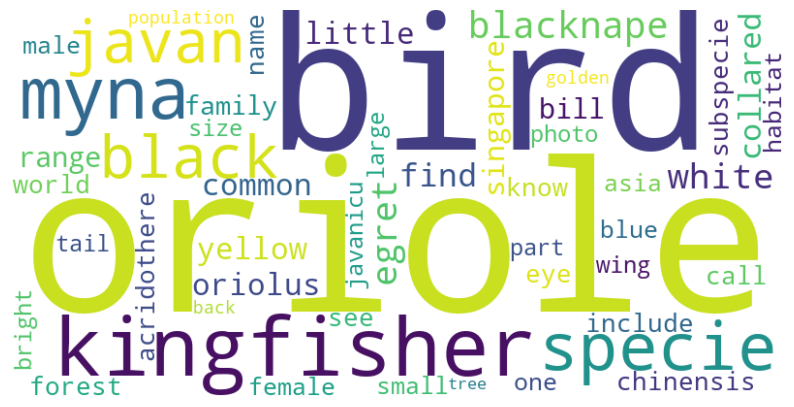

In [14]:
#This is a word cloud that shows top 50 word by count
from collections import Counter
import wordcloud
import matplotlib.pyplot as plt

# Combine all processed words into a single list
all_words = []
for row in pre_processing_df['processed_words']:
    all_words.extend(row.split(' '))  # Split words that were joined by ' '


word_counts = Counter(all_words)#Counter to count the frequency of each word occuring

wordcloud = wordcloud.WordCloud(width=800, height=400, background_color='white',max_words=50).generate_from_frequencies(word_counts)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Species Analysis using Box Plot

**Use a Box Plot to show you the species words distribution like value that is outliers(1.5 time more or below than sigma), mean and etc** <br>
**If you compare the after and before, the outliers are sightly reduced**

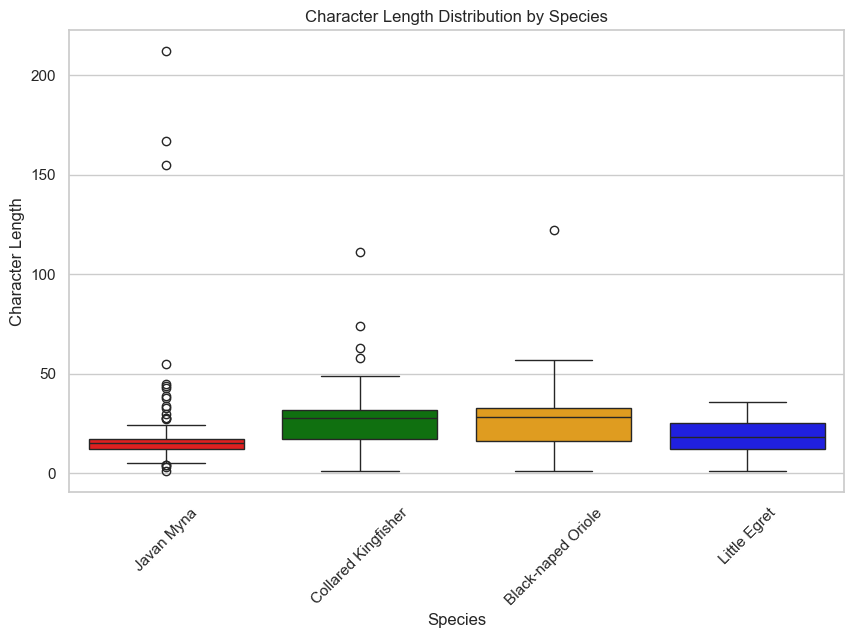

In [15]:
#Showing a box plot to show character length for each species to spot out how many outliers there are.

#calculate the character length of each description
pre_processing_df['char_length'] = pre_processing_df['processed_words'].apply(lambda x: len(x.split()))

# Set the style for the plot
sb.set(style="whitegrid")

# Define colours for the box plot
colours = ['red', 'green', 'orange', 'blue']

# Plot character length distribution by species
plt.figure(figsize=(10, 6)) #Specify the size of the box plot


sb.boxplot(x='species', y='char_length', data=pre_processing_df, hue='species', palette=colours)

# Set plot labels and title
plt.title('Character Length Distribution by Species') #Set title
plt.xlabel('Species') # Set X label
plt.ylabel('Character Length')# Set Y label

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

# This Pie chart and Bar Chart below shows the species and word count distribution
As you can see the distribution for each of the species from the below pie chart, **Little Egret** only consist of 19.55%. But when compared to **Black-naped Oriole** which as 30.19%, when training the model with this distribution, **Little Egret** will have lesser data to trains its part. Which might make detecting this species inaccurate.<br>
This is similar for the average word count per species bar chart below. **Little Egret** having the lowest average word count. <br>
Overall. We can assume that when training the models to predict **Little Egret**, since we have lesser data on this. It will be less accurate.

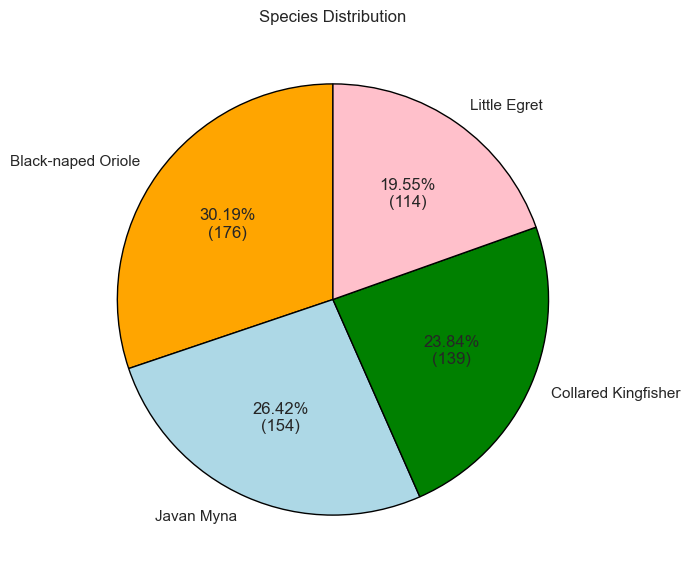

In [16]:
# Species Distribution Pie Chart
species_counts = pre_processing_df['species'].value_counts()  # Find the total count of each species
total_species_count = pre_processing_df['species'].count()  # Total species count

#Color for the bar chart
colors=['Orange','Lightblue','Green','Pink']

#Size of the pie chart
plt.figure(figsize=(7, 7))

# Create the pie chart
plt.pie(
    species_counts.values, # Values from the species count variable 
    labels=species_counts.index,  # Labels for each part of the pie chart
    colors=colors, #Color set to the colors list
    autopct=lambda p: f'{p:.2f}%\n({int(p * total_species_count / 100)})',  # autopct that calculate the percentage and count
    startangle=90,  # Sort the pie chart ascending
    wedgeprops={'edgecolor': 'black'}  # Add edge color for better visibility
)

plt.title('Species Distribution') #Set label
plt.show()


# Average Words count per species, Bar Chart

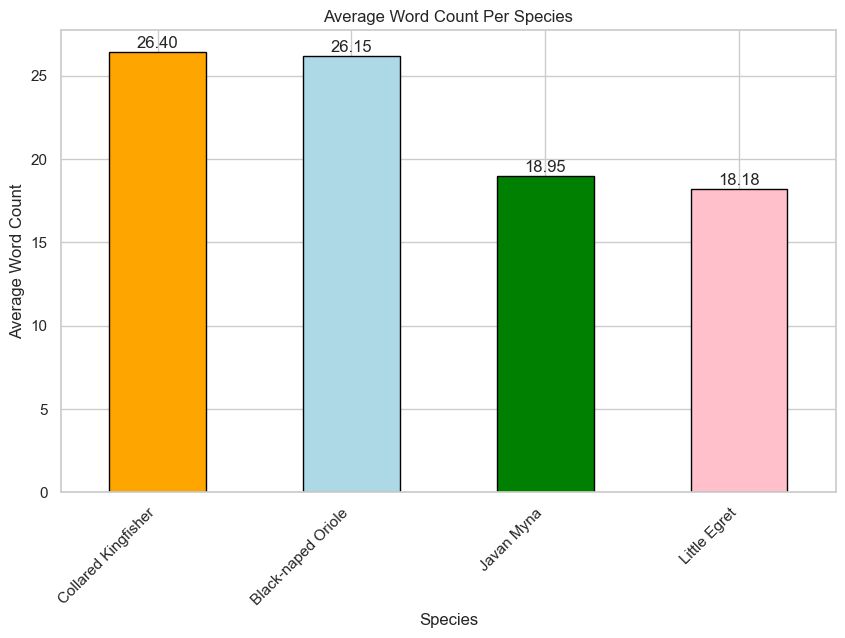

In [17]:
# Calculate word count of processed words
pre_processing_df['word_count'] = pre_processing_df['processed_words'].apply(lambda x: len(x.split()))

# Calculate the average word count per species
avg_word_per_species = pre_processing_df.groupby('species')['word_count'].mean().sort_values(ascending=False)

# Size of the bar chart
plt.figure(figsize=(10, 6))

#Color for the bar chart
colors=['Orange','Lightblue','Green','Pink']

#plot the bar chart using the variable avg_word_per_species
avg_word_per_species.plot(kind='bar', color=colors , edgecolor='black') #Specifed the color and gave the edge / border of each bar chart black
plt.title('Average Word Count Per Species')#set title
plt.xlabel('Species') # Set X label
plt.ylabel('Average Word Count')# Set Y Label
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

for index, value in enumerate(avg_word_per_species):# Added text / lavbel of the average word count for each species
    plt.text(index, value + 0.1, f'{value:.2f}', ha='center', va='bottom')

plt.show()
